In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Disable scientific notation, show plain numbers
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# List of all 7 encoder result files we saved throughout the project
encoder_files = [
    "onehot_scores.csv",
    "ordinal_scores.csv",
    "frequency_scores.csv",
    "target_scores.csv",
    "catboost_scores.csv",
    "binary_scores.csv",
    "hashing_scores.csv"
]

# Load each file and combine them into a single long-format DataFrame.
# Since every notebook saved results in the same structure (encoder, model,
# fold, rmse, mae, r2), this is a simple concatenation, no reshaping needed.
all_results = pd.concat([pd.read_csv(f) for f in encoder_files], ignore_index=True)

# Sanity check: should be 7 encoders x 5 models x 5 folds = 175 rows
print(f"Total rows: {len(all_results)}")
print(f"Unique encoders: {all_results['encoder'].unique()}")
print(f"Unique models: {all_results['model'].unique()}")

all_results.head()

Total rows: 350
Unique encoders: <StringArray>
['onehot', 'ordinal', 'frequency', 'target', 'catboost', 'binary', 'hashing']
Length: 7, dtype: str
Unique models: <StringArray>
['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Stacking']
Length: 5, dtype: str


,encoder,model,fold,rmse,mae,r2
0,onehot,Linear Regression,1,"2,528.74","1,489.96",0.97
1,onehot,Linear Regression,2,"2,627.94","1,470.63",0.96
2,onehot,Linear Regression,3,"2,451.79","1,464.83",0.97
3,onehot,Linear Regression,4,"2,593.41","1,508.83",0.97
4,onehot,Linear Regression,5,"2,319.72","1,427.55",0.97


In [3]:
# Pivot the data: rows = encoder, columns = model, values = mean RMSE across folds
# This gives us the core comparison table for the whole project
rmse_pivot = all_results.pivot_table(
    index="encoder",
    columns="model",
    values="rmse",
    aggfunc="mean"
)

rmse_pivot

model,Decision Tree,KNN,Linear Regression,Random Forest,Stacking
encoder,,,,,
binary,"2,987.25","2,853.57","4,909.93","2,109.26","2,112.78"
catboost,"2,695.87","2,297.07","4,206.24","1,937.83","1,926.27"
frequency,"2,995.47","2,611.64","5,086.87","2,125.13","2,134.18"
hashing,"3,384.71","3,327.77","5,123.93","2,411.14","2,434.26"
onehot,"2,829.11","3,692.23","2,499.77","2,048.83","2,026.10"
ordinal,"2,937.44","2,687.43","5,146.64","2,101.88","2,113.24"
target,"2,789.29","2,291.30","4,312.83","1,992.76","1,975.35"


In [4]:
# Same pivot, but for MAE
mae_pivot = all_results.pivot_table(
    index="encoder",
    columns="model",
    values="mae",
    aggfunc="mean"
)

mae_pivot

model,Decision Tree,KNN,Linear Regression,Random Forest,Stacking
encoder,,,,,
binary,"1,599.46","1,606.18","2,974.85","1,146.60","1,157.99"
catboost,"1,493.64","1,275.46","2,627.66","1,064.11","1,071.17"
frequency,"1,608.41","1,447.19","3,055.02","1,161.87","1,168.84"
hashing,"1,859.01","1,984.94","3,139.47","1,360.64","1,387.07"
onehot,"1,541.87","1,901.49","1,469.77","1,125.14","1,131.69"
ordinal,"1,597.52","1,551.79","3,102.53","1,154.38","1,175.68"
target,"1,501.09","1,277.30","2,678.04","1,076.88","1,085.63"


In [5]:
# Same pivot, but for R²
r2_pivot = all_results.pivot_table(
    index="encoder",
    columns="model",
    values="r2",
    aggfunc="mean"
)

r2_pivot

model,Decision Tree,KNN,Linear Regression,Random Forest,Stacking
encoder,,,,,
binary,0.95,0.96,0.88,0.98,0.98
catboost,0.96,0.97,0.91,0.98,0.98
frequency,0.95,0.97,0.87,0.98,0.98
hashing,0.94,0.94,0.87,0.97,0.97
onehot,0.96,0.93,0.97,0.98,0.98
ordinal,0.96,0.96,0.87,0.98,0.98
target,0.96,0.97,0.91,0.98,0.98


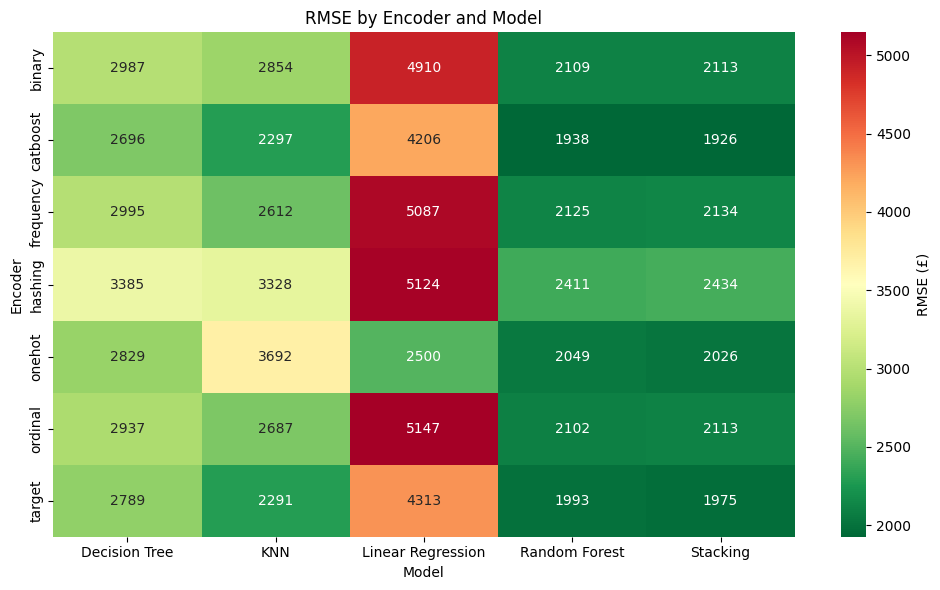

In [6]:
# This is likely the centerpiece visual of your results chapter:
# rows = encoder, columns = model, colour = RMSE (darker/lighter = better/worse)
plt.figure(figsize=(10, 6))
sns.heatmap(rmse_pivot, annot=True, fmt=".0f", cmap="RdYlGn_r", 
            cbar_kws={"label": "RMSE (£)"})
plt.title("RMSE by Encoder and Model")
plt.ylabel("Encoder")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("rmse_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

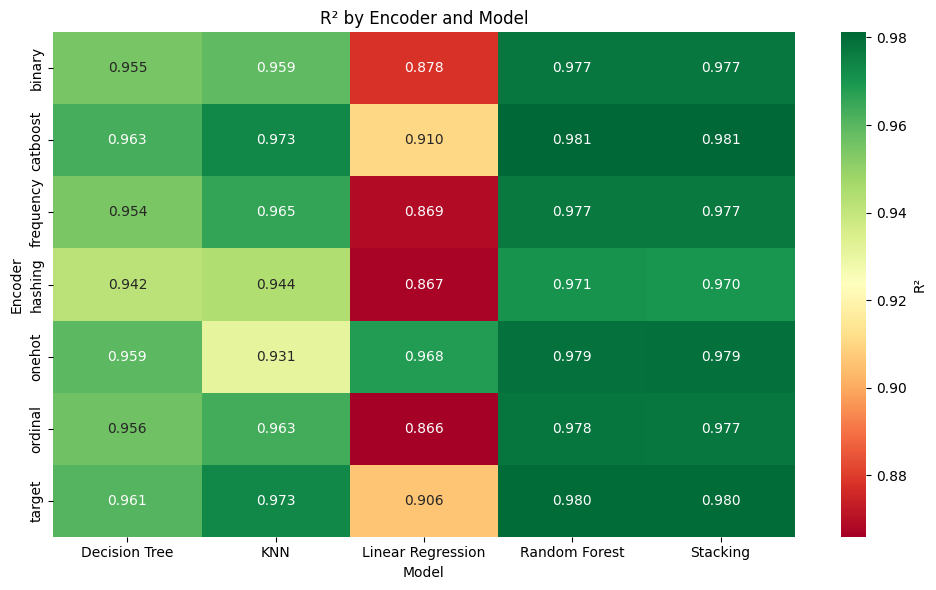

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="RdYlGn",
            cbar_kws={"label": "R²"})
plt.title("R² by Encoder and Model")
plt.ylabel("Encoder")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("r2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
from itertools import combinations

# Get the list of models and encoders
models = all_results["model"].unique()
encoders = all_results["encoder"].unique()

# We'll store every pairwise test result here
significance_results = []

# Loop through each model separately
for model in models:
    
    # Filter to just this model's results
    model_data = all_results[all_results["model"] == model]
    
    # For every possible PAIR of encoders (e.g. onehot vs catboost, onehot vs target, ...)
    for encoder_a, encoder_b in combinations(encoders, 2):
        
        # Get this encoder's RMSE score for EACH fold, in fold order
        # This is critical: both arrays must be ordered by fold so that
        # fold 1 lines up with fold 1, fold 2 with fold 2, etc. (paired comparison)
        scores_a = model_data[model_data["encoder"] == encoder_a].sort_values("fold")["rmse"].values
        scores_b = model_data[model_data["encoder"] == encoder_b].sort_values("fold")["rmse"].values
        
        # Run the Wilcoxon signed-rank test on these paired fold scores
        # This tells us whether the difference between encoder_a and encoder_b
        # is statistically significant, or could just be random fold variation
        try:
            stat, p_value = stats.wilcoxon(scores_a, scores_b)
        except ValueError:
            # Wilcoxon fails if all differences are exactly zero (identical scores)
            # This shouldn't happen with real data, but we handle it safely just in case
            p_value = np.nan
        
        # Record which encoder actually performed better (lower RMSE = better)
        better_encoder = encoder_a if scores_a.mean() < scores_b.mean() else encoder_b
        
        significance_results.append({
            "model": model,
            "encoder_a": encoder_a,
            "encoder_b": encoder_b,
            "mean_rmse_a": scores_a.mean(),
            "mean_rmse_b": scores_b.mean(),
            "better_encoder": better_encoder,
            "p_value": p_value,
            "significant": p_value < 0.05 if not np.isnan(p_value) else False
        })

significance_df = pd.DataFrame(significance_results)
print(f"Total pairwise comparisons: {len(significance_df)}")
significance_df.head(10)

Total pairwise comparisons: 105


,model,encoder_a,encoder_b,mean_rmse_a,mean_rmse_b,better_encoder,p_value,significant
0,Linear Regression,onehot,ordinal,"2,499.77","5,146.64",onehot,0.00,True
1,Linear Regression,onehot,frequency,"2,499.77","5,086.87",onehot,0.00,True
2,Linear Regression,onehot,target,"2,499.77","4,312.83",onehot,0.00,True
3,Linear Regression,onehot,catboost,"2,499.77","4,206.24",onehot,0.00,True
4,Linear Regression,onehot,binary,"2,499.77","4,909.93",onehot,0.00,True
5,Linear Regression,onehot,hashing,"2,499.77","5,123.93",onehot,0.00,True
6,Linear Regression,ordinal,frequency,"5,146.64","5,086.87",frequency,0.00,True
7,Linear Regression,ordinal,target,"5,146.64","4,312.83",target,0.00,True
8,Linear Regression,ordinal,catboost,"5,146.64","4,206.24",catboost,0.00,True
9,Linear Regression,ordinal,binary,"5,146.64","4,909.93",binary,0.00,True


In [9]:
# Show only the comparisons that turned out to be statistically significant
# (p < 0.05), sorted by model, these are the differences you can confidently
# report as "real" in your dissertation, not just numerical noise
significant_only = significance_df[significance_df["significant"] == True].sort_values(["model", "p_value"])
significant_only

,model,encoder_a,encoder_b,mean_rmse_a,mean_rmse_b,better_encoder,p_value,significant
43,Decision Tree,onehot,frequency,"2,829.11","2,995.47",onehot,0.00,True
47,Decision Tree,onehot,hashing,"2,829.11","3,384.71",onehot,0.00,True
52,Decision Tree,ordinal,hashing,"2,937.44","3,384.71",ordinal,0.00,True
54,Decision Tree,frequency,catboost,"2,995.47","2,695.87",catboost,0.00,True
56,Decision Tree,frequency,hashing,"2,995.47","3,384.71",frequency,0.00,True
...,...,...,...,...,...,...,...,...
101,Stacking,target,hashing,"1,975.35","2,434.26",target,0.00,True
102,Stacking,catboost,binary,"1,926.27","2,112.78",catboost,0.00,True
103,Stacking,catboost,hashing,"1,926.27","2,434.26",catboost,0.00,True
104,Stacking,binary,hashing,"2,112.78","2,434.26",binary,0.00,True


In [10]:
# Quick summary: out of all pairwise comparisons for each model, how many
# were statistically significant? A high proportion means encoder choice
# genuinely matters a lot for that model; a low proportion means most
# encoders perform similarly for that model, differences are just noise
summary_significance = significance_df.groupby("model")["significant"].agg(["sum", "count"])
summary_significance["pct_significant"] = (summary_significance["sum"] / summary_significance["count"] * 100).round(1)
summary_significance.columns = ["significant_pairs", "total_pairs", "pct_significant"]
summary_significance

,significant_pairs,total_pairs,pct_significant
model,,,
Decision Tree,16,21,76.20
KNN,20,21,95.20
Linear Regression,21,21,100.00
Random Forest,19,21,90.50
Stacking,18,21,85.70


In [11]:
significance_df.to_csv("statistical_significance.csv", index=False)
print("Saved to statistical_significance.csv")

Saved to statistical_significance.csv
